# Test of origin of replication deconvolution with fixed offset configs

In [214]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1048]:
o = origins.sort_values(eff_key, ascending=False)
o = o[o.activation_time == 'late']
o

,chr,pos,strand,footprint_class,nucleosome_shift_class,mcm_loading_class,activation_time,derived_origin_efficiency_from_mcguffee_et_al_2013,acs_sequence,log2_acs_motif_score,ars_name,ars_start,ars_end,oridb_status
name,,,,,,,,,,,,,,
oridb_126,4,123794,-,g1_and_g2_footprint,downstream,upstream,late,0.8108,TTAATATATATTTAGTTACTTTTTCCCTCTAAT,15.4106,ARS406,123616,123901,Confirmed
oridb_498,11,612412,-,g1_and_g2_footprint,static,downstream,late,0.7361,TTTTTTTATGTTTTTGGCTCCTAGAGGTGAATA,14.0135,ARS1120,612240,612473,Confirmed
oridb_193,4,1353585,+,g1_and_g2_footprint,upstream,upstream,late,0.7143,CAAATTAATATTTATGAACGTTATGATGTCAAG,8.0574,ARS437,1353506,1353679,Confirmed
oridb_558,12,888741,-,g1_and_g2_footprint,downstream,downstream,late,0.7121,GTTTTTTATGTTTAGATGTAAAAATTAATTTTT,20.0399,ARS1227.5,888569,888810,Confirmed
oridb_121,4,46229,-,g1_and_g2_footprint,static,upstream,late,0.6938,AAATTTAATATTTTGGATGAAAAAAACCATTTT,11.5099,ARS404,46180,46236,Confirmed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oridb_807,16,608624,-,g1_and_g2_footprint,static,downstream,late,-0.3633,TATATTTTATTTTTGTTATTTTTCTGACGTATC,10.2164,NaN,608479,609679,Dubious
oridb_94,3,54938,-,g1_and_g2_footprint,downstream,upstream,late,-0.5451,CTTTTTTTTTTTTTGTTACATAAAACTTTGCTT,9.1369,NaN,53807,55007,Dubious
oridb_336,8,7756,-,g1_and_g2_footprint,static,downstream,late,-1.0000,TATTTTTATATTTAGGTGATTTTAGTGGTTATT,23.2374,ARS802,7535,7783,Confirmed


In [1058]:
# origin_sweep.print_efficient_origins()
selected_origins = [
    'oridb_10', # ARS107 
    'oridb_295', # ARS718
    'oridb_289',
    'oridb_498', # ARS1120, late
    'oridb_193', # late
    'oridb_558' # late
]

In [1064]:
def deconvolve_and_plot_model(origin_sweep, config_mode, title, selected_origins,
                             gamma=0.01):
    """
    Create a single plot for a model with multiple origins as rows
    
    Parameters:
    -----------
    config_mode : str
        Configuration mode ('cloccs', 'draft1', or 'draft2')
    title : str
        Title for the plot
    selected_origins : list
        List of origin IDs to plot
    output_dir : str
        Output directory for saving figures
    """
    
    # Load the appropriate configuration
    origin_sweep.load_configs(config_mode)
    
    # Create a figure with 4 rows (one for each origin) and 3 columns 
    # (replicates 1, 2, combined)
    fig, axes = plt.subplots(len(selected_origins), 3, 
                             figsize=(11, 3 * len(selected_origins)))
    
    # Process each origin
    for row, oridb in enumerate(selected_origins):
        # Analyze the origin
        footprint = origin_sweep.analyze_origin(oridb)
        
        # For each replicate type (1, 2, combined)
        for col, replicate in enumerate([1, 2, 'combined']):
            # Set the current subplot
            if len(selected_origins) > 1:
                plt.sca(axes[row, col])
            else:
                plt.sca(axes[col])  # Handle case with only one origin
                
            if col > 0: plt.yticks([])
            if row < len(selected_origins)-1: plt.xticks([])
            
            # Set up and perform deconvolution
            origin_sweep.setup_footprint_deconvolution(replicate=replicate)                
            origin_sweep.deconvolve_footprint(gamma=gamma)
            
            # Plot the results
            origin_sweep.plot_deconvolved_footprint(fig=fig)
            
            # Set y-axis limits
            plt.ylim(0, 2.5)
            
            # Add labels for the first column
            if col == 0:
                plt.ylabel(f"Origin {oridb}", fontsize=12)
    
    # Add overall title
    plt.suptitle(title, y=1.015, fontweight='demi', fontsize=16)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save figure
    from src.figure_configs import save_figure_for_paper
    save_figure_for_paper(f'output/origins_model_comparison/{title.replace(":", "_")}.png')
    
    return fig


Loading chromosome reads: 1
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 1000) to (16, 26, 100)
Loading chromosome reads: 1
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (15, 251, 1000) to (15, 26, 100)
Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
0/91 - 00:00:00.000
Completed - 00:00:07.849
0/91 - 00:00:00.000
Completed - 00:00:07.507
0/91 - 00

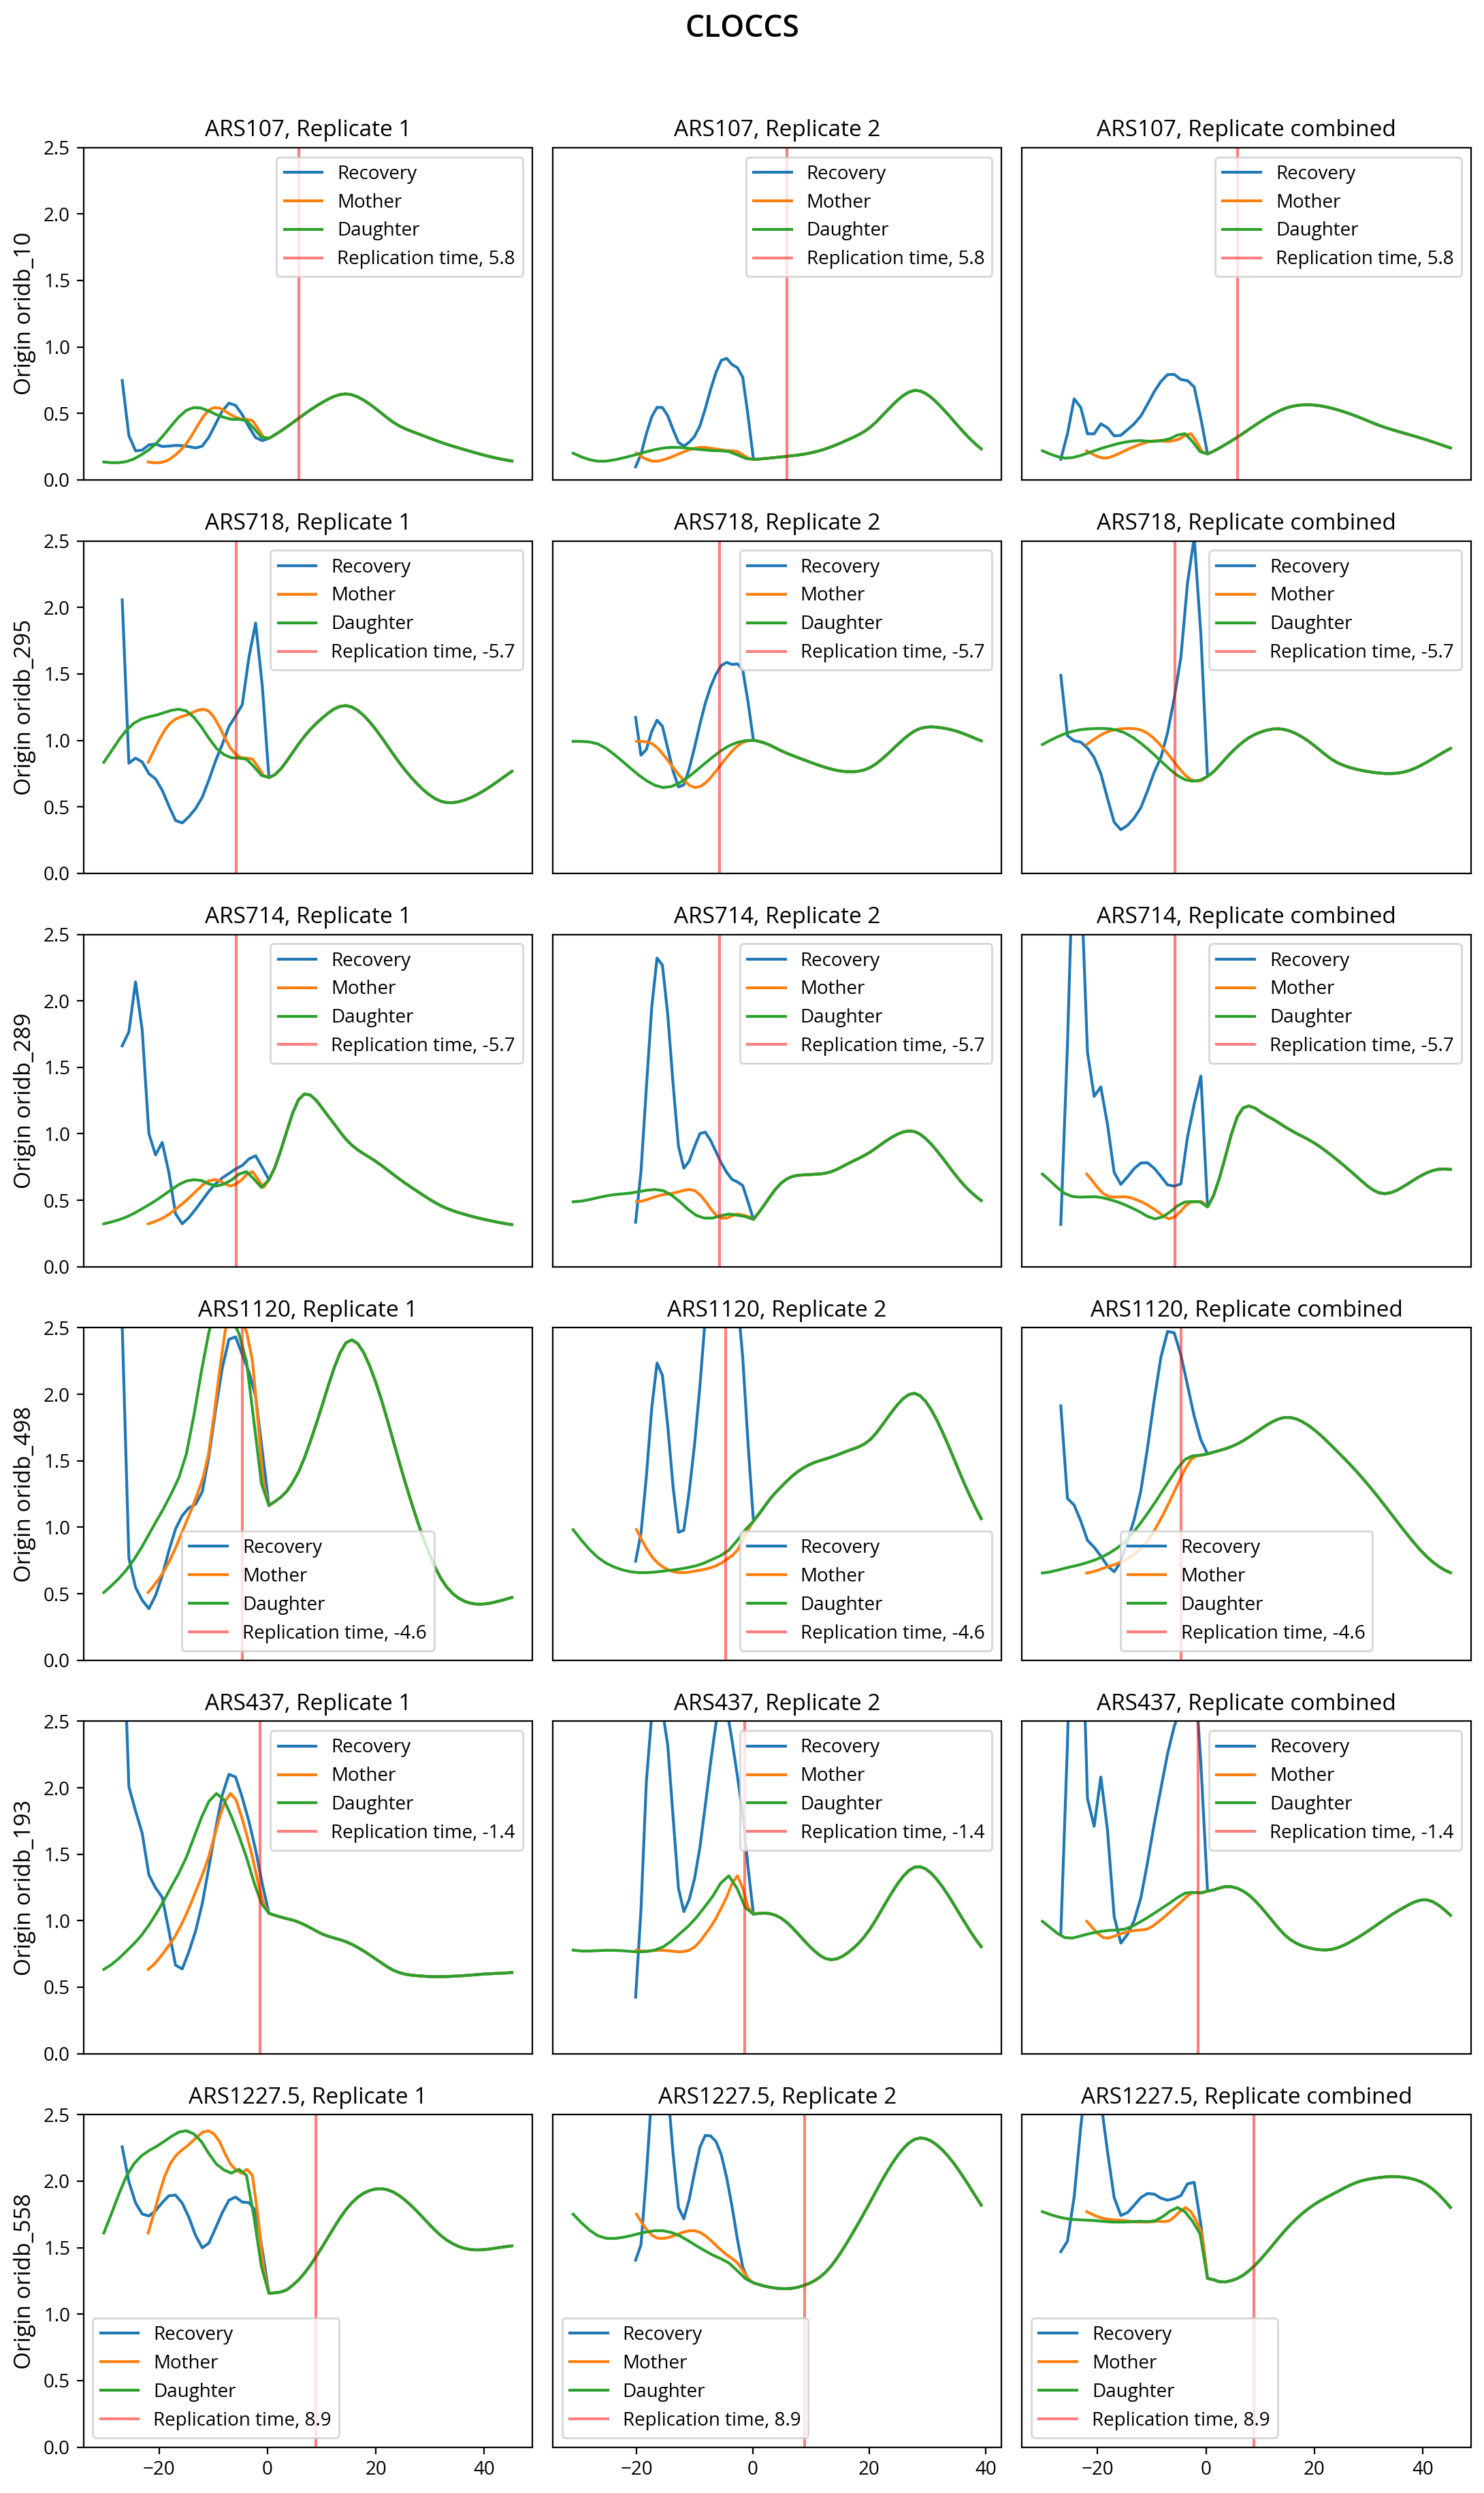

Loading chromosome reads: 1
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 1000) to (16, 26, 100)
Loading chromosome reads: 1
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (15, 251, 1000) to (15, 26, 100)
Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
0/91 - 00:00:00.000
Completed - 00:00:07.345
0/91 - 00:00:00.000
Completed - 00:00:07.327
0/91 - 00

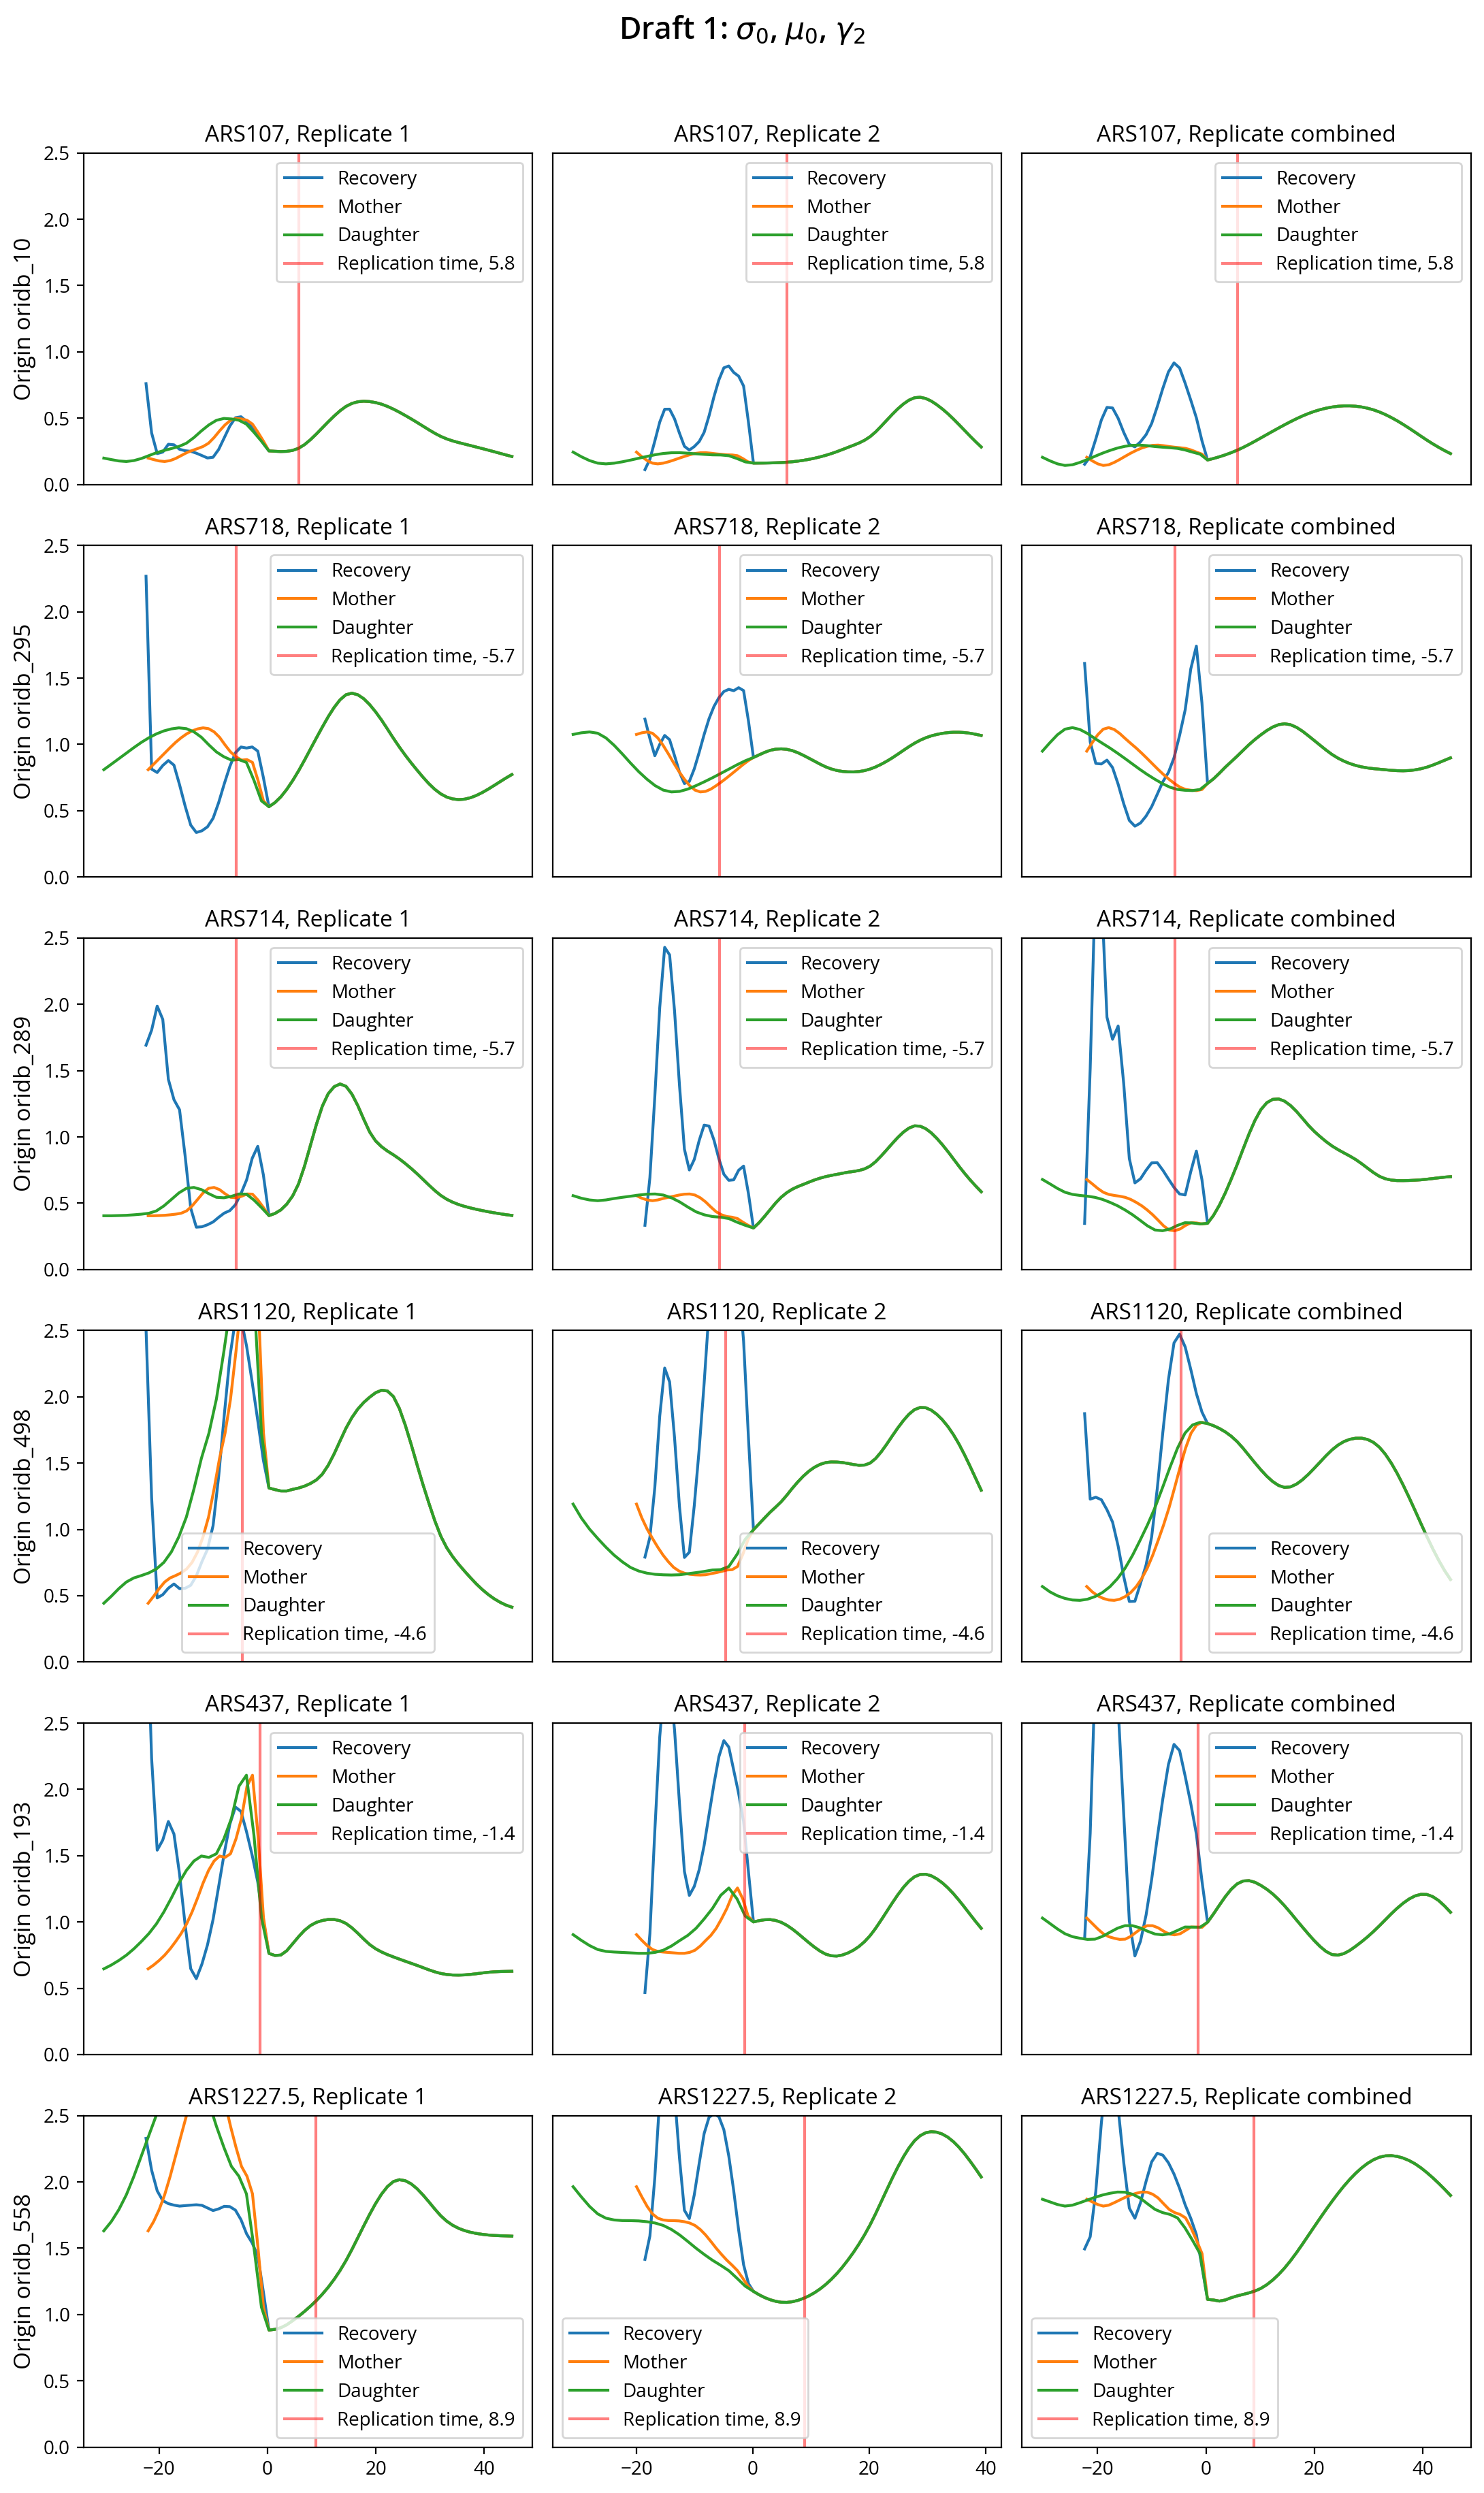

In [1073]:
from pipeline.origin_alpha_sweep import OriginAlphaSweep
import matplotlib.pyplot as plt

# Initialize the sweep object
origin_sweep = OriginAlphaSweep('output/draft1_run/')
    
# Define models and their titles
config_modes = ['cloccs', 'draft1']
titles = [
    'CLOCCS', 
    "Draft 1: $\\sigma_0$, $\\mu_0$, $\\gamma_2$",
]

# Create one plot per model
for i, config_mode in enumerate(config_modes):
    fig = deconvolve_and_plot_model(
        origin_sweep,
        config_mode=config_mode,
        title=titles[i],
        selected_origins=selected_origins,
        gamma=0.001)
    
    # Display the figure (optional, remove if not needed)
    plt.figure(fig.number)
    plt.show()

In [1266]:
from src.origins import load_origins
origins = load_origins(full=True)
origin_sweep.origins = origins

origins[origins.footprint_class == 'g1_only_footprint'].sort_values(eff_key,
                                                                   ascending=False).head(20)



,chr,pos,strand,footprint_class,nucleosome_shift_class,mcm_loading_class,activation_time,derived_origin_efficiency_from_mcguffee_et_al_2013,acs_sequence,log2_acs_motif_score,ars_name,ars_start,ars_end,oridb_status
name,,,,,,,,,,,,,,
oridb_653,14,322003,+,g1_only_footprint,downstream,upstream,early,0.7717,TTTGTTTACGTTTAGGCGAAATACTCACCTCTT,17.0958,ARS1415,321920,322213,Confirmed
oridb_395,9,214735,+,g1_only_footprint,downstream,downstream,early,0.7674,TTAATTTATGTTTTGTAAAGAATAAAATGAGTA,13.8691,ARS913,214678,214829,Confirmed
oridb_386,9,105967,-,g1_only_footprint,static,upstream,early,0.7423,ATTATTCATGTTTTCTTTTAATTATCGAGCTTT,16.3731,ARS909,105821,106048,Confirmed
oridb_177,4,1016855,-,g1_only_footprint,downstream,downstream,early,0.7291,TTTGTTTACGTTTTGGAGGAAAACTAATTATTT,15.3707,ARS430,1016633,1016931,Confirmed
oridb_762,16,73205,-,g1_only_footprint,static,downstream,early,0.7012,GTCTTTATTGTTTAGTCTCAATAATCGCAATTA,14.9639,ARS1605,73038,73283,Confirmed
oridb_739,15,855010,-,g1_only_footprint,downstream,downstream,late,0.6621,TATATATATATATATTTATATATATTAGATTTT,10.9683,ARS1525,854738,855231,Confirmed
oridb_220,5,145715,-,g1_only_footprint,upstream,downstream,early,0.6561,CAGTTTTTTGTTTAGTTTTTTAATCTGGATATT,17.7048,ARS510,145540,145783,Confirmed
oridb_155,4,702931,+,g1_only_footprint,downstream,upstream,late,0.6559,ATAATTAATGTTTTGGTCTGAATTTTTATTTTT,21.3241,ARS422,702886,703132,Confirmed
oridb_142,4,435164,+,g1_only_footprint,upstream,downstream,early,0.6550,GAAATAAATATTTAGTTGAGAAAGTTTTGTTTA,11.6790,ARS415,435060,435392,Confirmed


In [1270]:
#origin_sweep = OriginAlphaSweep('output/draft1_run/')
origin_sweep.origins = origins

In [ ]:
origin

In [1405]:

config1, config2 = load_cloccs_configs()
#config2.params_dic.update({'mu': -26, 'lambda': 66})

origin_sweep = OriginAlphaSweep('output/draft1_run/')
origin_sweep.origins = origins
origin_sweep.load_configs(config1, config2)


Loading chromosome reads: 9
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 1000) to (16, 26, 100)
Loading chromosome reads: 9
Imputing timepoint 50 as average of 40 and 60
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (15, 251, 1000) to (15, 26, 100)
Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/


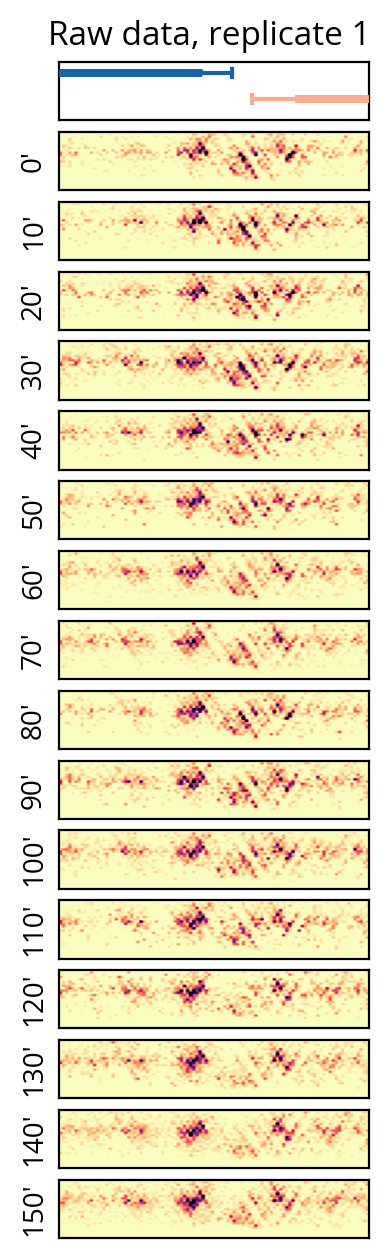

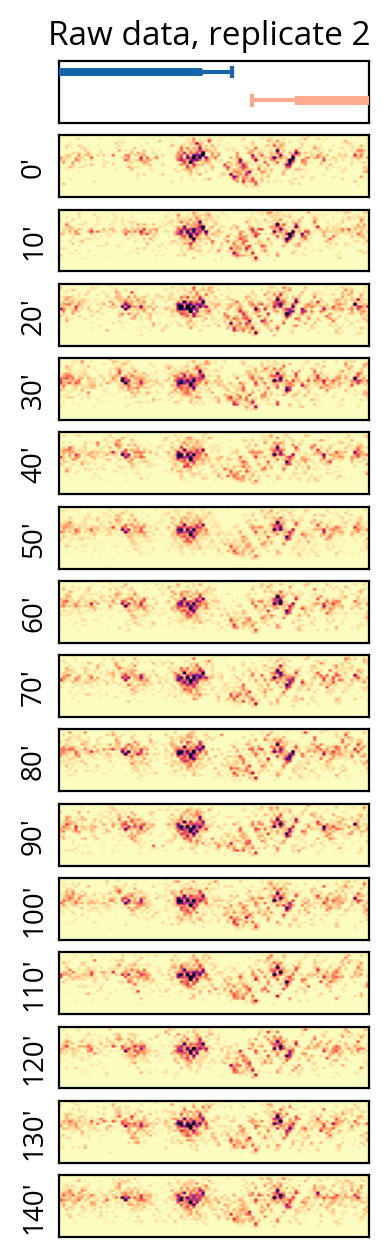

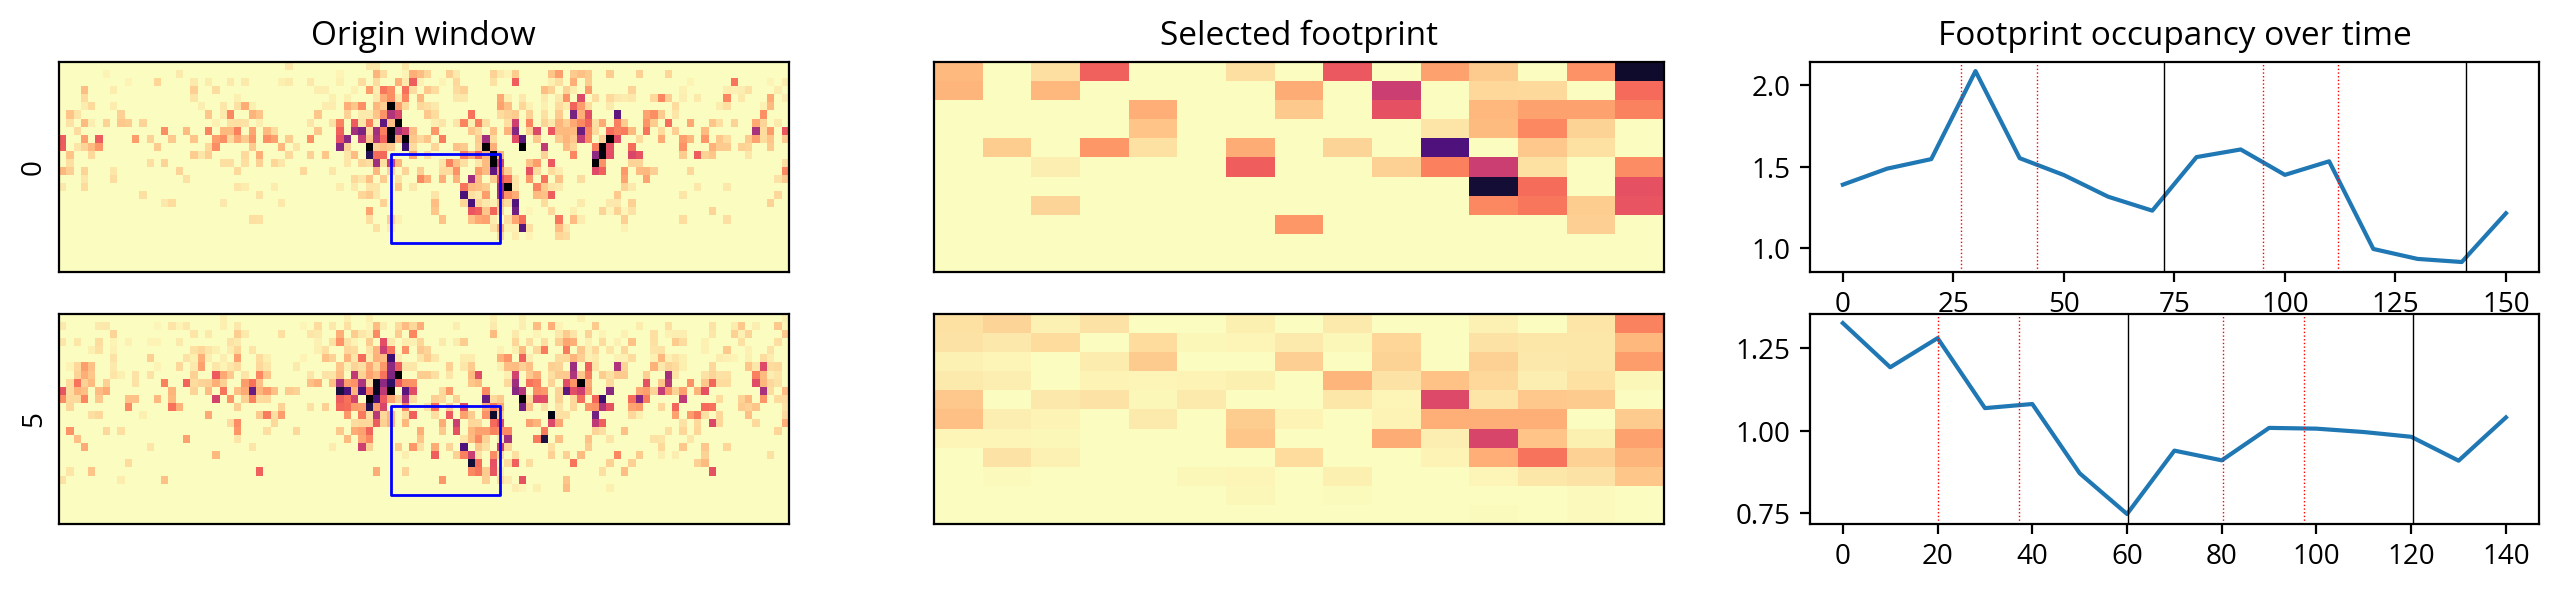

In [1406]:
footprint = origin_sweep.analyze_origin('oridb_395', plot=True)

Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr
0/165 - 00:00:00.000
Completed - 00:00:16.964


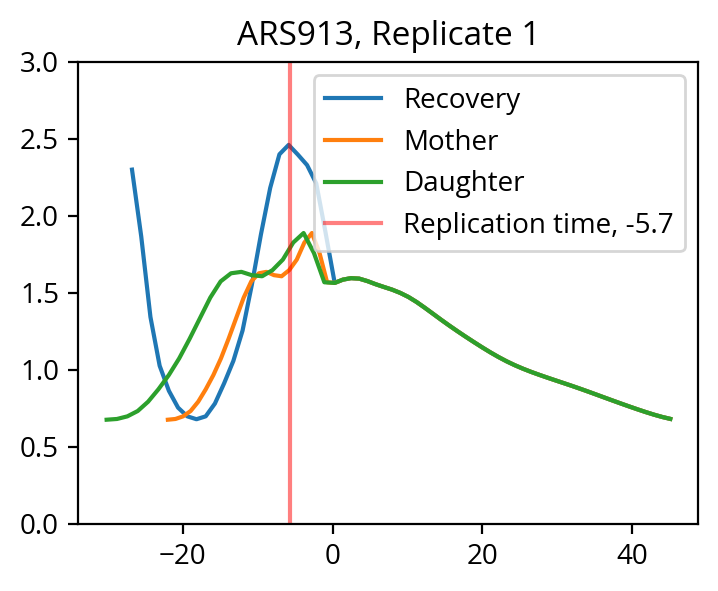

In [1418]:
config1.modify_alpha(22)
origin_sweep.config1 = config1

origin_sweep.footprint_config = config1

origin_sweep.setup_footprint_deconvolution(replicate=1, copy_correct=False)
origin_sweep.solver.update_config_and_H(config1, config1.H)

origin_sweep.deconvolve_footprint(gamma=0.002)
origin_sweep.plot_deconvolved_footprint(fig=None)


Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr
0/165 - 00:00:00.000
Completed - 00:00:17.433


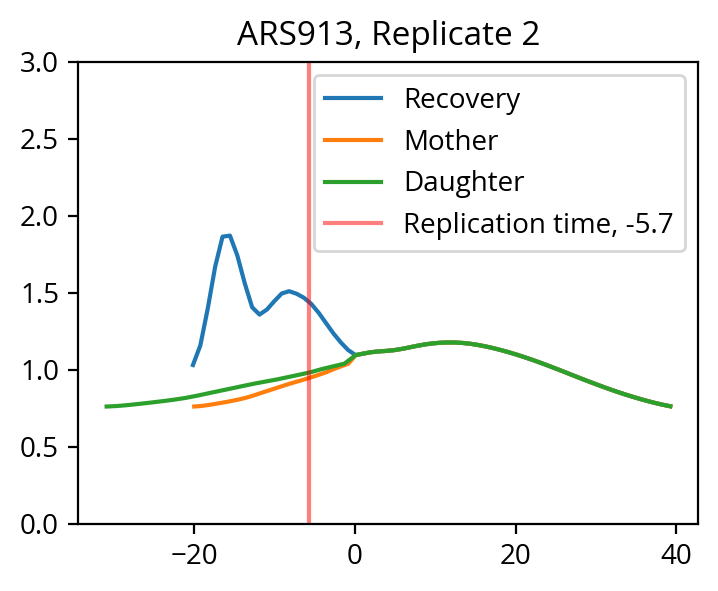

In [1419]:
config2.modify_alpha(20)

origin_sweep.config2 = config2

origin_sweep.footprint_config = config2

origin_sweep.setup_footprint_deconvolution(replicate=2, copy_correct=False)
origin_sweep.solver.update_config_and_H(config2, config2.H)

origin_sweep.deconvolve_footprint(gamma=0.002)
origin_sweep.plot_deconvolved_footprint(fig=None)


Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr
0/165 - 00:00:00.000
Completed - 00:00:18.624


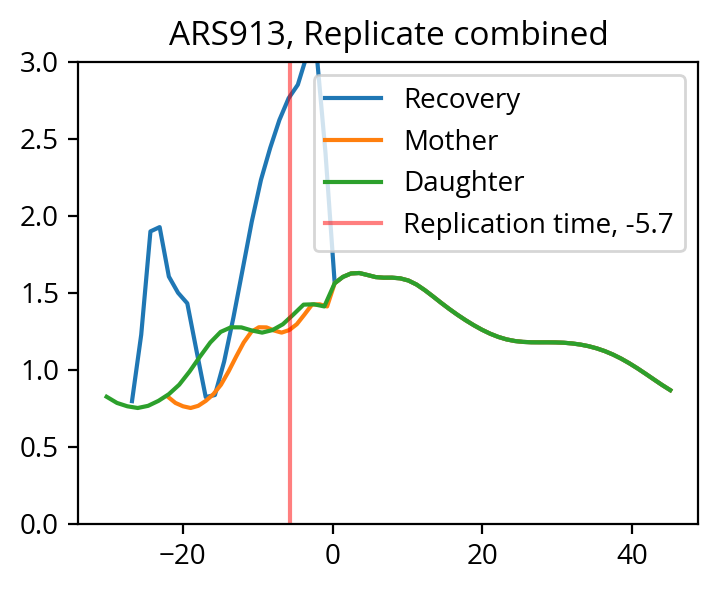

In [1421]:
config1.modify_alpha(22)
config2.modify_alpha(20)

origin_sweep.config1 = config1
origin_sweep.config2 = config2

H = np.concatenate([config1.H, config2.H])

origin_sweep.footprint_config = config1

origin_sweep.setup_footprint_deconvolution(replicate='combined', copy_correct=False)
origin_sweep.solver.update_config_and_H(config1, H)

origin_sweep.deconvolve_footprint(gamma=0.001)
origin_sweep.plot_deconvolved_footprint(fig=None)
